In [12]:
import os
import numpy as np
import matplotlib.pyplot as plt

RESULTS_DIR = './results'

label_fontsize = 18

In [13]:
import torch

use_cuda = torch.cuda.is_available()
use_mps = torch.backends.mps.is_available() and False

if use_cuda:
    device = torch.device("cuda")
elif use_mps:
    device = torch.device("mps")
else:
    device = torch.device("cpu")

device

device(type='cuda')

In [14]:
from src.spectral_cka import predict_cka

## Construct gram matrix of brain, model1, model2. All have power-law spectrum, but different eigenvectors


In [15]:
def construct_gram_matrices(P=200, random_seed=42):
    """
    Constructs Gram matrices for Brain, Model1, and Model2 with specified eigenvector overlap constraints.
    All overlaps between indices 0-5 are set to 0 except for the explicitly specified constraints.

    Parameters:
    - P (int): Dimension of the Gram matrices.
    - random_seed (int): Seed for random number generator for reproducibility.

    Returns:
    - dict: Dictionary containing Gram matrices and eigenvectors.
    """
    # Set random seed for reproducibility
    np.random.seed(random_seed)

    # Define eigenvalues: lambda_i = 1 / (i + 1)
    eigenvalues = np.ones(P)
    for i in range(P):
        eigenvalues[i] = (i+1)**(-1.2)
    Lambda = np.diag(eigenvalues).astype(np.float64)

    # Define Brain Gram Matrix (Diagonal with eigenvalues)
    G_brain = Lambda.copy()

    # Initialize Brain eigenvectors as standard basis
    U_brain = np.eye(P).astype(np.float64)

    def random_orthonormal_vector(existing_vectors):
        """
        Generates a random unit vector orthogonal to all vectors in existing_vectors.
        """
        while True:
            vec = np.random.randn(P).astype(np.float64)
            if existing_vectors.size > 0:
                proj = existing_vectors.T @ vec
                vec = vec - existing_vectors @ proj
            norm = np.linalg.norm(vec)
            if norm > 1e-10:
                return vec / norm

    def construct_model(overlaps, model_name):
        """
        Constructs an orthonormal set of eigenvectors for a model with specified overlaps.
        Ensures all other overlaps between indices 0-5 are zero.

        Parameters:
        - overlaps (list of tuples): Each tuple contains (model_idx, brain_idx, overlap_val).
        - model_name (str): Name of the model for error messages.

        Returns:
        - np.ndarray: Matrix of model eigenvectors with shape (P, P).
        """
        U_model = np.zeros((P, P))
        assigned_columns = set()

        # Create a set of specified overlaps for quick lookup
        specified_overlaps = {(m_idx, b_idx) for m_idx, b_idx, _ in overlaps}

        # First, handle the explicitly specified overlaps
        for (model_idx, brain_idx, overlap_val) in overlaps:
            if model_idx < 0 or model_idx >= P:
                raise ValueError(f"{model_name}: model_idx {model_idx} out of bounds for P={P}")
            if brain_idx < 0 or brain_idx >= P:
                raise ValueError(f"{model_name}: brain_idx {brain_idx} out of bounds for P={P}")
            if overlap_val < 0 or overlap_val > 1:
                raise ValueError(f"{model_name}: Invalid overlap_val {overlap_val}. Must be between 0 and 1.")

            sqrt_overlap = np.sqrt(overlap_val)
            sqrt_rest = np.sqrt(1.0 - overlap_val)

            # Start with the specified brain eigenvector component
            u = sqrt_overlap * U_brain[:, brain_idx]

            # Make orthogonal to all previously assigned vectors
            existing_vectors = U_model[:, list(assigned_columns)].copy() if assigned_columns else np.empty((P, 0))

            # Also make orthogonal to brain eigenvectors 0-5 (except the current one)
            # to ensure zero overlap with non-specified indices
            brain_vectors = []
            for i in range(6):  # indices 0-5
                if i != brain_idx and (model_idx, i) not in specified_overlaps:
                    brain_vectors.append(U_brain[:, i])
            if brain_vectors:
                brain_basis = np.column_stack(brain_vectors).astype(np.float64)
                if existing_vectors.size > 0:
                    existing_vectors = np.column_stack([existing_vectors, brain_basis]).astype(np.float64)
                else:
                    existing_vectors = brain_basis

            v = random_orthonormal_vector(existing_vectors)
            u += sqrt_rest * v

            # Normalize
            u /= np.linalg.norm(u)

            U_model[:, model_idx] = u.astype(np.float64)
            assigned_columns.add(model_idx)

        # For indices 0-5 that weren't explicitly specified, ensure zero overlap with all brain vectors 0-5
        for model_idx in range(6):
            if model_idx not in assigned_columns:
                existing_vectors = U_model[:, list(assigned_columns)].copy() if assigned_columns else np.empty((P, 0))

                # Make orthogonal to all brain vectors 0-5
                brain_vectors = [U_brain[:, i] for i in range(6)]
                if existing_vectors.size > 0:
                    existing_vectors = np.column_stack([existing_vectors, np.column_stack(brain_vectors)])
                else:
                    existing_vectors = np.column_stack(brain_vectors)

                v = random_orthonormal_vector(existing_vectors)
                U_model[:, model_idx] = v.astype(np.float64)
                assigned_columns.add(model_idx)

        # Fill remaining columns
        for model_idx in range(P):
            if model_idx not in assigned_columns:
                existing_vectors = U_model[:, list(assigned_columns)].copy().astype(
                    np.float64) if assigned_columns else np.empty((P, 0))
                v = random_orthonormal_vector(existing_vectors)
                U_model[:, model_idx] = v.astype(np.float64)
                assigned_columns.add(model_idx)

        # Ensure orthonormality
        Q, R = np.linalg.qr(U_model.astype(np.float64))
        return Q

    # Define Model1 Constraints
    model1_overlaps = [
        (5, 0, 0.65),
        (4, 1, 0.65),
        (3, 2, 0.65)
    ]

    # Define Model2 Constraints
    model2_overlaps = [
        (0, 5, 0.9),
        (1, 4, 0.7),
        (2, 3, 0.7)
    ]

    U_model1 = construct_model(model1_overlaps, "Model1").astype(np.float64)
    U_model2 = construct_model(model2_overlaps, "Model2").astype(np.float64)

    # Construct Gram Matrices
    G_model1 = U_model1 @ Lambda @ U_model1.T
    G_model2 = U_model2 @ Lambda @ U_model2.T

    def verify_overlaps(U_model, overlaps, model_name):
        """
        Verifies that the specified overlaps are satisfied and other overlaps between indices 0-5 are zero.
        """
        print(f"\n{model_name} Eigenvector Overlaps (tilde_M):")
        tilde_M = (U_model ** 2).T  # Shape: (P, P), tilde_M[i,j] = |U_model[j,i]|^2

        # First check specified overlaps
        for (model_idx, brain_idx, expected_val) in overlaps:
            actual_val = tilde_M[model_idx, brain_idx]
            print(f"tilde_{model_name}[{model_idx},{brain_idx}] = {actual_val:.4f} (Expected: {expected_val})")

        # Then check that other overlaps between indices 0-5 are zero
        specified_pairs = {(m_idx, b_idx) for m_idx, b_idx, _ in overlaps}
        print(f"\nVerifying zero overlaps for other pairs between indices 0-5:")
        for i in range(12):
            for j in range(12):
                if (i, j) not in specified_pairs:
                    val = tilde_M[i, j]
                    if val > 1e-10:
                        print(f"WARNING: tilde_{model_name}[{i},{j}] = {val:.4f} (Expected: 0.0)")

    # Verification Output
    print("Gram matrices constructed successfully.")
    print("\nVerifying Constraints:")
    verify_overlaps(U_model1, model1_overlaps, "M1")
    verify_overlaps(U_model2, model2_overlaps, "M2")

    def check_orthonormality(U, model_name):
        """
        Checks if the eigenvectors are orthonormal.
        """
        identity = np.eye(U.shape[1])
        orthonormal = np.allclose(U.T @ U, identity, atol=1e-10)
        print(f"\n{model_name} Eigenvectors Orthonormality: {'Passed' if orthonormal else 'Failed'}")

    # Check Orthonormality
    check_orthonormality(U_model1, "Model1")
    check_orthonormality(U_model2, "Model2")

    print(np.trace(G_brain@G_model1)/np.sqrt(np.trace(G_brain**2)*np.trace(G_model1**2)))
    print(np.trace(G_brain@G_model2)/np.sqrt(np.trace(G_brain**2)*np.trace(G_model2**2)))
    print(np.trace(G_model1@G_model2)/np.sqrt(np.trace(G_model1**2)*np.trace(G_model2**2)))

    return {
        "G_brain": G_brain,
        "G_model1": G_model1,
        "G_model2": G_model2,
        "U_brain": U_brain,
        "U_model1": U_model1,
        "U_model2": U_model2,
        "Lambda": Lambda
    }

In [16]:
gram_matrices = construct_gram_matrices()

Gram matrices constructed successfully.

Verifying Constraints:

M1 Eigenvector Overlaps (tilde_M):
tilde_M1[5,0] = 0.6551 (Expected: 0.65)
tilde_M1[4,1] = 0.6528 (Expected: 0.65)
tilde_M1[3,2] = 0.6444 (Expected: 0.65)

Verifying zero overlaps for other pairs between indices 0-5:

M2 Eigenvector Overlaps (tilde_M):
tilde_M2[0,5] = 0.8998 (Expected: 0.9)
tilde_M2[1,4] = 0.7009 (Expected: 0.7)
tilde_M2[2,3] = 0.7109 (Expected: 0.7)

Verifying zero overlaps for other pairs between indices 0-5:

Model1 Eigenvectors Orthonormality: Passed

Model2 Eigenvectors Orthonormality: Passed
0.519961845461012
0.1916124924574619
0.15670877467586494


In [17]:
# Extract Gram matrices
U_brain = gram_matrices["U_brain"]    # NumPy array
U_model1 = gram_matrices["U_model1"]  # NumPy array
U_model2 = gram_matrices["U_model2"]  # NumPy array

# Check orthonormality
P = len(U_brain)
assert np.allclose(U_brain.T @ U_brain, np.eye(P))
assert np.allclose(U_model1.T @ U_model1, np.eye(P))
assert np.allclose(U_model2.T @ U_model2, np.eye(P))

U_m = U_model1
U_m[:, 0] = U_model1[:, 1]
U_m[:, 1] = U_model1[:, 0]

np.sum((U_brain[:, :].T @ U_m[:, :4])**2/P)

0.019999999999999997

In [18]:
# Extract Gram matrices
brain_G = gram_matrices["G_brain"]    # NumPy array
model1_G = gram_matrices["G_model1"]  # NumPy array
model2_G = gram_matrices["G_model2"]  # NumPy array

# Convert Gram matrices to PyTorch tensors
brain_G = torch.from_numpy(brain_G).to(torch.float64)
model1_G = torch.from_numpy(model1_G).to(torch.float64)
model2_G = torch.from_numpy(model2_G).to(torch.float64)

# Ensure all matrices are on the same device (CPU)
device = torch.device('cpu')
brain_G = brain_G.to(device)
model1_G = model1_G.to(device)
model2_G = model2_G.to(device)

# Define the dimension
P = brain_G.shape[0]


def matrix_sqrt(A):
    """
    Computes the matrix square root of a positive semi-definite matrix A.

    Parameters:
    - A (torch.Tensor): Symmetric positive semi-definite matrix.

    Returns:
    - torch.Tensor: The matrix square root of A.
    """
    eigvals, eigvecs = torch.linalg.eigh(A)
    eigvals_clamped = torch.clamp(eigvals, min=0.0)
    sqrt_eigvals = torch.sqrt(eigvals_clamped)
    sqrt_Lambda = torch.diag(sqrt_eigvals)
    sqrt_A = eigvecs @ sqrt_Lambda @ eigvecs.t()
    return sqrt_A


brain_act = matrix_sqrt(brain_G)
model1_act = matrix_sqrt(model1_G)
model2_act = matrix_sqrt(model2_G)

## Do forward, backward analysis


In [19]:
from collections import defaultdict
neuron_sizes = np.logspace(1.3, 3, 8, dtype=int)


def run_multiple_cka_iterations(brain_act, model_act, neuron_sizes, n_iterations=5, cutoff=200, num_inner_iterations=3):
    """
    Run CKA analysis multiple times and collect results for each neuron size.

    Parameters:
    -----------
    brain_act : array-like
        Brain activation data
    model_act : array-like
        Model activation data
    neuron_sizes : array-like
        Array of neuron sizes to test
    n_iterations : int, optional
        Number of times to repeat the analysis (default: 10)
    cutoff : int, optional
        Cutoff parameter for predict_cka function (default: 200)
    num_inner_iterations : int, optional
        Number of iterations for predict_cka function (default: 3)

    Returns:
    --------
    dict : Dictionary containing results for each neuron size, where each metric
           has n_iterations values
    """
    # Initialize nested defaultdict to store results
    super_results = defaultdict(lambda: defaultdict(list))

    # Metrics we want to track
    metrics = ['naive_cka_final', 'predicted_cka_final', 'estimated_cka_final',
               'naive_cca_final', 'predicted_cca_final', 'estimated_cca_final']

    # Run iterations
    for _ in range(n_iterations):
        # For each neuron size
        for size in neuron_sizes:
            # Wrap the single size in a list for predict_cka
            size_as_array = np.array([size])

            # Get results for current iteration
            results = predict_cka(brain_act, model_act, size_as_array,
                                  cutoff=cutoff,
                                  num_iterations=num_inner_iterations)

            # Store each metric for this neuron size
            for metric in metrics:
                # Since we passed a single size, the result will be for that size
                super_results[size][metric].append(results[metric])

    return dict(super_results)


filename = RESULTS_DIR + f"/cka_cca_ranking_flip.npz"

if not os.path.exists(filename):
    super_results1 = run_multiple_cka_iterations(brain_act, model1_act, neuron_sizes)
    super_results2 = run_multiple_cka_iterations(brain_act, model2_act, neuron_sizes)
    np.savez(filename, super_results1=super_results1, super_results2=super_results2)

else:
    data = np.load(filename, allow_pickle=True)
    super_results1 = data['super_results1'].item()
    super_results2 = data['super_results2'].item()

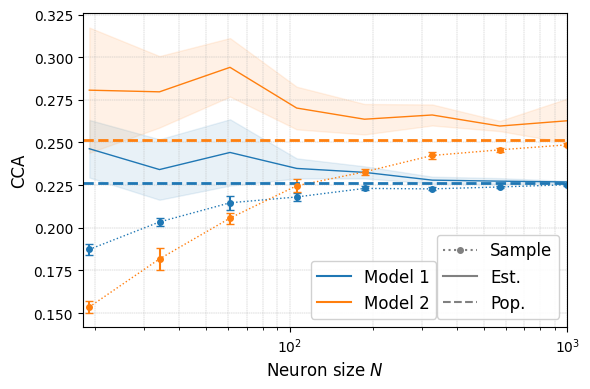

In [20]:
plt.style.use('default')
plt.figure(figsize=(6, 4))

# Define metrics based on type
metric_type = 'cca'  # or 'cka'
metrics = {
    'naive': f'naive_{metric_type}_final',
    'estimated': f'estimated_{metric_type}_final'
}

# Calculate means and stds for both models
results = {
    'model1': {name: {
        'means': [np.mean(super_results1[size][metric]) for size in neuron_sizes],
        'stds': [np.std(super_results1[size][metric]) for size in neuron_sizes]
    } for name, metric in metrics.items()},
    'model2': {name: {
        'means': [np.mean(super_results2[size][metric]) for size in neuron_sizes],
        'stds': [np.std(super_results2[size][metric]) for size in neuron_sizes]
    } for name, metric in metrics.items()}
}

# Style definitions
styles = {
    'naive': {'line': ':', 'marker': '.', 'markersize': 8},
    'estimated': {'line': '-', 'marker': None, 'markersize': 0}
}

colors = {'model1': 'C0', 'model2': 'C1'}

# Create proxy artists for legend
style_lines = [
    plt.Line2D([0], [0], color='gray', marker='.', linestyle=':',
               markersize=8, label='Sample'),
    plt.Line2D([0], [0], color='gray', linestyle='-',
               label='Est.'),
    plt.Line2D([0], [0], color='gray', linestyle='--',
               label='Pop.')
]

model_lines = [
    plt.Line2D([0], [0], color='C0', linestyle='-', label='Model 1'),
    plt.Line2D([0], [0], color='C1', linestyle='-', label='Model 2')
]

# Plot for each model and metric
for model_name, model_results in results.items():
    color = colors[model_name]

    # Plot naive (sample) points with error bars
    plt.errorbar(neuron_sizes, model_results['naive']['means'],
                 model_results['naive']['stds'],
                 fmt='.', color=color, capsize=3, capthick=1, markersize=8)

    # Add dotted line connecting sample means
    plt.plot(neuron_sizes, model_results['naive']['means'], ':',
             color=color, linewidth=1)

    # Plot estimated with cloud
    plt.plot(neuron_sizes, model_results['estimated']['means'], '-',
             color=color, linewidth=1)
    plt.fill_between(neuron_sizes,
                     np.array(model_results['estimated']['means']) - np.array(model_results['estimated']['stds']),
                     np.array(model_results['estimated']['means']) + np.array(model_results['estimated']['stds']),
                     color=color, alpha=0.1)

# Add horizontal lines
plt.axhline(y=0.22652255234422913, color='C0', linestyle='--', linewidth=2)
plt.axhline(y=0.25151810380410605, color='C1', linestyle='--', linewidth=2)

# Styling
plt.xlabel(r"Neuron size $N$", fontsize=12)
plt.ylabel(metric_type.upper(), fontsize=12)
plt.grid(True, which='both', linestyle='--', linewidth=0.3)
plt.xlim([neuron_sizes[0]-1, neuron_sizes[-1]])

# Adjust tick label sizes
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Add two separate legends
leg1 = plt.legend(handles=model_lines, loc='lower center',
                  fontsize=12, framealpha=0.9, bbox_to_anchor=(0.6, 0.0))
plt.gca().add_artist(leg1)

plt.legend(handles=style_lines, loc='lower right',
           fontsize=12, framealpha=0.9, bbox_to_anchor=(1.0, 0.0))

plt.xscale('log')
plt.tight_layout()
plt.show()

P=200, N1=200, N2=200, True CKA: 0.14792505845215204, True CCA: 0.22652258210934811
Neuron_size=19/200
199 5.598642349724514e-08
182 6.13117880909897e-08
134 3.939063208946436e-08
219 2.132207210792103e-08
232 1.6342242226130566e-08
191 6.0060524109673e-08
269 9.794772548588071e-08
150 4.2092730634379905e-08
153 4.135939590810267e-09
151 6.251393047662646e-08
120 4.619041926723355e-08
P=200, N1=200, N2=200, True CKA: 0.1609860013485188, True CCA: 0.251518117847423
Neuron_size=19/200
225 9.391842903383463e-08
201 7.393859968729544e-08
352 9.202713568967624e-08
156 4.3424636331224065e-08
268 6.82539811336369e-08
369 5.54943468955571e-09
570 9.962292857323973e-08
186 2.2364029295118826e-08
283 8.708868737272724e-09
249 3.6897292332582765e-08
117 3.2866170007750384e-08


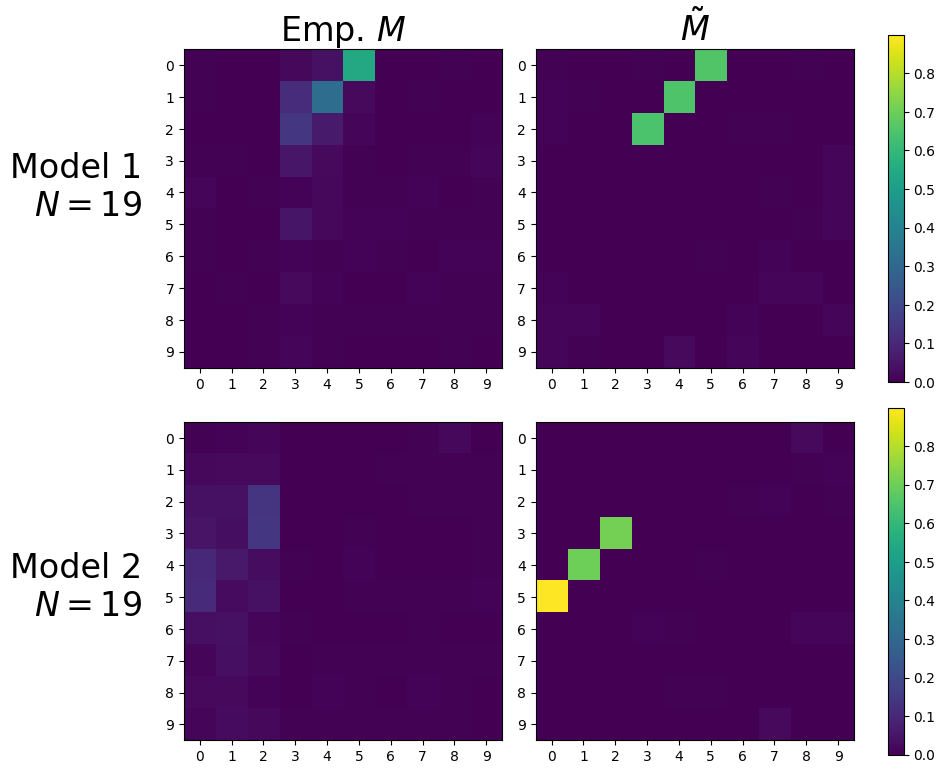

In [21]:
neuron_sizes = np.logspace(1.3, 3, 1, dtype=int)
results1 = predict_cka(brain_act, model1_act, neuron_sizes, cutoff=200, num_iterations=10)
results2 = predict_cka(brain_act, model2_act, neuron_sizes, cutoff=200, num_iterations=10)


# Create one figure with two rows
fig = plt.figure(figsize=(8, 8))  # Adjusted size since we have fewer columns
gs = plt.GridSpec(2, 3, width_ratios=[1, 1, 0.05], height_ratios=[1, 1])

titles = ['Emp. $M$', '$\\tilde{M}$']
N_idx = 0  # modify this to choose different N
N = neuron_sizes[N_idx]
plot_threshold = 10

# Collect only first and last matrices for both models
# For Model 1
M_avg1 = np.array(results1['M_emp_mean'][N_idx][:plot_threshold, :plot_threshold])
M_tilde1 = np.array(results1['M_tilde'][N_idx][:plot_threshold, :plot_threshold])
matrices_model1 = [M_avg1, M_tilde1]

# For Model 2
M_avg2 = np.array(results2['M_emp_mean'][N_idx][:plot_threshold, :plot_threshold])
M_tilde2 = np.array(results2['M_tilde'][N_idx][:plot_threshold, :plot_threshold])
matrices_model2 = [M_avg2, M_tilde2]

# Find global min/max across all matrices
all_matrices = matrices_model1 + matrices_model2
vmin = min(m.min() for m in all_matrices)
vmax = max(m.max() for m in all_matrices)

# Plot Model 1 (top row)
plt.figtext(-0.01, 0.75, f'Model 1\n$N={N}$', fontsize=24, ha='right', va='center')
for col, (matrix, title) in enumerate(zip(matrices_model1, titles)):
    ax = plt.subplot(gs[0, col])
    im = ax.imshow(matrix, cmap='viridis', vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=24)
    ax.set_xticks(range(10))
    ax.set_yticks(range(10))

    # Add colorbar for the row
    if col == len(matrices_model1) - 1:
        cax = plt.subplot(gs[0, -1])
        plt.colorbar(im, cax=cax)

# Plot Model 2 (bottom row)
plt.figtext(-0.01, 0.25, f'Model 2\n$N={N}$', fontsize=24, ha='right', va='center')
for col, (matrix, title) in enumerate(zip(matrices_model2, titles)):
    ax = plt.subplot(gs[1, col])
    im = ax.imshow(matrix, cmap='viridis', vmin=vmin, vmax=vmax)
    ax.set_xticks(range(10))
    ax.set_yticks(range(10))

    # Add colorbar for the row
    if col == len(matrices_model2) - 1:
        cax = plt.subplot(gs[1, -1])
        plt.colorbar(im, cax=cax)

plt.tight_layout()
plt.show()